# Biogas NPV simulation

Run the biogas electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [13]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity_npv_monte_carlo import simulate_biogas_npv


In [ ]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_biogas_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,biogas,1000000.0,5300.0,188.679245,188679.245283,5310.436839,300.605130,5.094285,2.508990,...,94070000.0,5.671795e+07,5.094285e+06,2.195367e+08,0.0,-1.872789e+08,-3.001130e+09,25000000.0,-120.045180,-0.000120
1,1,biogas,1000000.0,5300.0,188.679245,188679.245283,4620.427354,163.739369,3.896680,2.614202,...,94070000.0,3.089422e+07,3.896680e+06,2.287427e+08,0.0,-1.694636e+08,-2.680765e+09,25000000.0,-107.230588,-0.000107
2,2,biogas,1000000.0,5300.0,188.679245,188679.245283,3729.970221,243.148623,3.971182,2.614738,...,94070000.0,4.587710e+07,3.971182e+06,2.287896e+08,0.0,-1.845679e+08,-2.673988e+09,25000000.0,-106.959539,-0.000107
3,3,biogas,1000000.0,5300.0,188.679245,188679.245283,3018.301846,258.453653,4.383673,2.547107,...,94070000.0,4.876484e+07,4.383673e+06,2.228719e+08,0.0,-1.819504e+08,-2.511770e+09,25000000.0,-100.470814,-0.000100
4,4,biogas,1000000.0,5300.0,188.679245,188679.245283,5711.755819,152.666049,4.377983,2.460413,...,94070000.0,2.880491e+07,4.377983e+06,2.152862e+08,0.0,-1.543991e+08,-2.725865e+09,25000000.0,-109.034607,-0.000109


In [15]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
npv_million_eur_per_mwh = results["npv_million_eur_per_mwh"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
        npv_million_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh,NPV million EUR/MWh
count,1000000.000000,1000000.000000,1000000.000000
mean,-2615.218580,-104.608743,-0.000105
std,208.230004,8.329200,0.000008
min,-3239.473385,-129.578935,-0.000130
5%,-2960.165178,-118.406607,-0.000118
50%,-2614.935473,-104.597419,-0.000105
95%,-2270.552808,-90.822112,-0.000091
max,-2007.800281,-80.312011,-0.000080


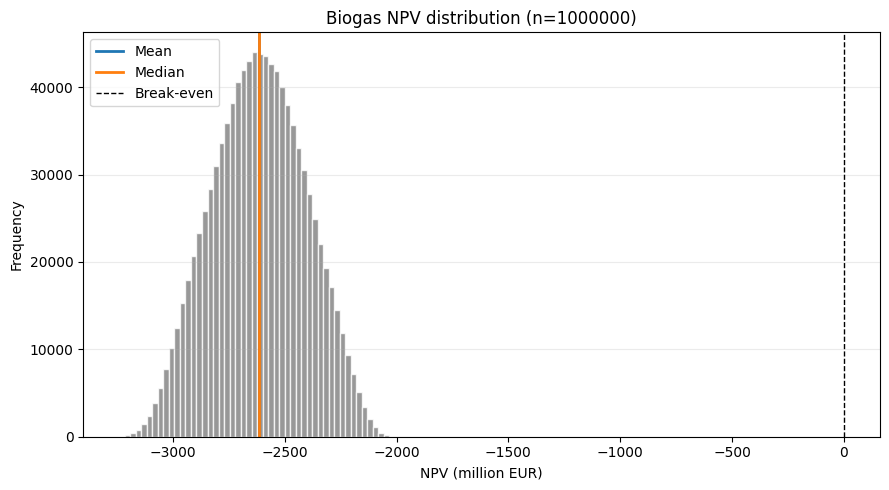

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Biogas NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


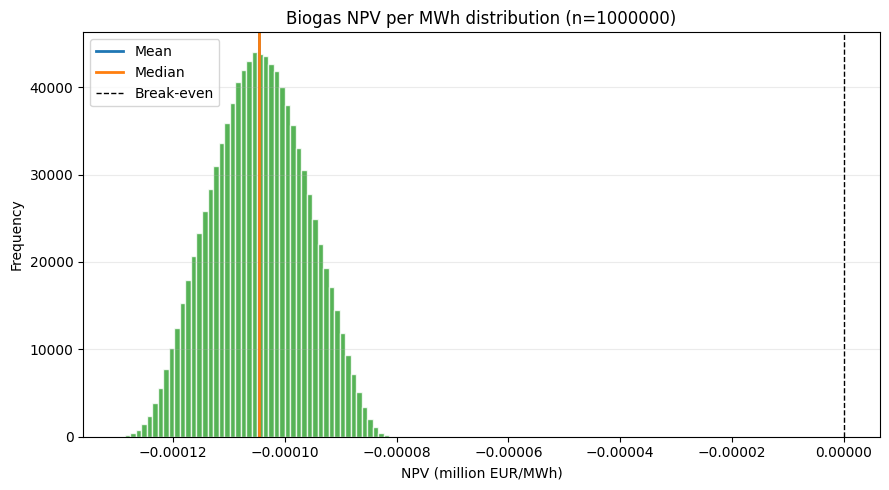

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_million_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_million_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_million_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Biogas NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [18]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur            94.070000
annual_fixed_opex_eur         37.144310
annual_variable_opex_eur       4.133272
annual_fuel_cost_eur         221.080356
annual_emissions_cost_eur      0.000000
annual_net_cash_flow_eur    -168.287938
Name: Mean annual value, million EUR, dtype: float64